# DATA 266 Lab 1 — Part 2: Yelp Polarity Sentiment Classification

**Goal:** train and compare three binary sentiment classifiers using **only embeddings learned from scratch**. No pretrained embeddings and no pretrained language model are used.

This notebook is intentionally split into small, auditable steps matching the Part 2 rubric: preprocessing, three models, full evaluation metrics, McNemar tests, robustness slices, 20-error review candidates, hardware disclosure, checkpoints, and saved artifacts.

**Dataset:** `fancyzhx/yelp_polarity` (Hugging Face)


## 0. Environment and Reproducibility

I set the random seed before loading the data and training the models. I also checked whether a GPU was available, created the required output and checkpoint folders, and saved the runtime information for reproducibility.

The saved environment details include the Python and PyTorch versions, device information, and hardware used for the run.


In [1]:
from pathlib import Path
from collections import Counter
from types import SimpleNamespace
import json, math, os, random, re, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    brier_score_loss, f1_score
)
from scipy.stats import chi2

SEED = 3143
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SRC_DIR = Path.cwd()
ROOT_DIR = SRC_DIR.parent
OUT_DIR = ROOT_DIR / 'outputs'
CKPT_DIR = ROOT_DIR / 'checkpoints'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA:', torch.version.cuda)
print('Working directory:', SRC_DIR)
print('Output directory:', OUT_DIR)


PyTorch: 2.14.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
CUDA: 13.0
Working directory: /app/Lab1_Submission/Part2_Sentiment/src
Output directory: /app/Lab1_Submission/Part2_Sentiment/outputs


## 1. Configuration

The official Yelp Polarity train/test splits are shuffled deterministically. From the official training split, we use **100,000 training reviews** and **10,000 validation reviews**. From the official test split, we use **20,000 test reviews**.

The validation set is used for checkpoint selection; the test set is reserved for the final metrics and statistical comparisons.


In [2]:
args = SimpleNamespace(
    dataset_id='fancyzhx/yelp_polarity',
    train_n=100_000,
    validation_n=10_000,
    test_n=20_000,
    vocab_size=40_000,
    max_length=256,
    batch_size=256,
    epochs=5,
    bootstrap_resamples=500,
    num_workers=0,
)

print(vars(args))


{'dataset_id': 'fancyzhx/yelp_polarity', 'train_n': 100000, 'validation_n': 10000, 'test_n': 20000, 'vocab_size': 40000, 'max_length': 256, 'batch_size': 256, 'epochs': 5, 'bootstrap_resamples': 500, 'num_workers': 0}


## 2.1 Data Preprocessing

### 2.1.1 Load the Dataset

I loaded the Yelp Polarity dataset using the namespaced Hugging Face dataset ID. This avoids the repository-ID error that can occur when using the older single-segment name.


In [3]:
raw_train_full = load_dataset(args.dataset_id, split='train')
raw_test_full = load_dataset(args.dataset_id, split='test')

print(raw_train_full)
print(raw_test_full)
print('Columns:', raw_train_full.column_names)
print('First example:', raw_train_full[0])


README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  256MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 17.7MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 560000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 38000
})
Columns: ['text', 'label']
First example: {'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.", 'label': 0}


### 2.1.2 Create deterministic train / validation / test subsets

Shuffling before selection avoids relying on the source dataset's row ordering.


In [4]:
raw_train_full = raw_train_full.shuffle(seed=SEED)
raw_test_full = raw_test_full.shuffle(seed=SEED)

needed = args.train_n + args.validation_n
train_pool = raw_train_full.select(range(min(needed, len(raw_train_full))))
train_raw = train_pool.select(range(args.train_n))
validation_raw = train_pool.select(range(args.train_n, args.train_n + args.validation_n))
test_raw = raw_test_full.select(range(min(args.test_n, len(raw_test_full))))

print('Train:', len(train_raw))
print('Validation:', len(validation_raw))
print('Test:', len(test_raw))


Train: 100000
Validation: 10000
Test: 20000


### 2.1.3 Missing Values and Malformed Entries

I checked the review text and labels before training. Empty or non-string review entries were identified, and labels were checked to make sure they belonged to the expected binary classes, 0 and 1.


In [5]:
def data_quality_report(ds, name):
    missing_text = 0
    malformed_label = 0
    empty_text = 0
    for row in ds:
        text = row.get('text', None)
        label = row.get('label', None)
        if text is None or not isinstance(text, str):
            missing_text += 1
        elif not text.strip():
            empty_text += 1
        if label not in (0, 1):
            malformed_label += 1
    return {
        'split': name,
        'rows': len(ds),
        'missing_or_non_string_text': missing_text,
        'empty_text': empty_text,
        'malformed_label': malformed_label,
    }

quality_df = pd.DataFrame([
    data_quality_report(train_raw, 'train'),
    data_quality_report(validation_raw, 'validation'),
    data_quality_report(test_raw, 'test'),
])
display(quality_df)


,split,rows,missing_or_non_string_text,empty_text,malformed_label
0,train,100000,0,0,0
1,validation,10000,0,0,0
2,test,20000,0,0,0


### 2.1.4 Class distribution and class balance

Yelp Polarity is a binary problem. We verify the selected subsets remain approximately balanced before training.


,split,label,count,percentage
0,train,0,50044,50.044
1,train,1,49956,49.956
2,validation,0,4921,49.210
3,validation,1,5079,50.790
4,test,0,10040,50.200
5,test,1,9960,49.800


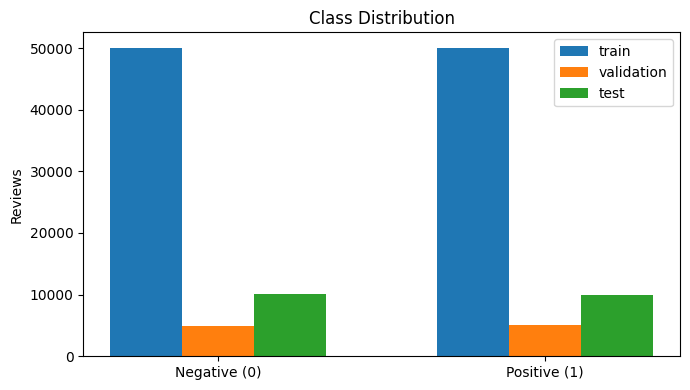

In [6]:
def class_counts(ds, split_name):
    labels = np.asarray(ds['label'])
    return pd.DataFrame({
        'split': [split_name, split_name],
        'label': [0, 1],
        'count': [(labels == 0).sum(), (labels == 1).sum()],
        'percentage': [(labels == 0).mean() * 100, (labels == 1).mean() * 100],
    })

class_balance_df = pd.concat([
    class_counts(train_raw, 'train'),
    class_counts(validation_raw, 'validation'),
    class_counts(test_raw, 'test'),
], ignore_index=True)
display(class_balance_df)

fig, ax = plt.subplots(figsize=(7, 4))
for i, split in enumerate(['train', 'validation', 'test']):
    part = class_balance_df[class_balance_df['split'] == split]
    ax.bar(np.array([0, 1]) + (i-1)*0.22, part['count'], width=0.22, label=split)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
ax.set_ylabel('Reviews')
ax.set_title('Class Distribution')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'class_distribution.png', dpi=160, bbox_inches='tight')
plt.show()


### 2.1.5 Review-length distribution

We measure raw word counts before truncation. This is later reused to define robustness slices (short / medium / long reviews).


,split,mean_words,median_words,p95_words,max_words
0,train,133.75054,97.0,375.00,1052
1,validation,132.71570,96.0,378.05,986
2,test,132.60700,97.0,369.05,972


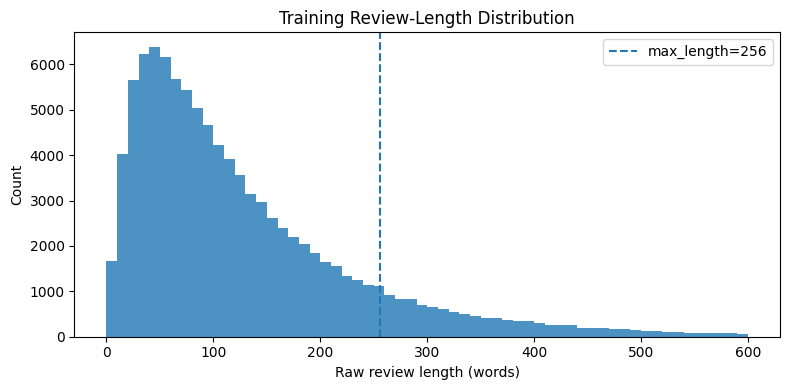

In [7]:
def raw_word_lengths(ds):
    return np.asarray([len(str(t).split()) for t in ds['text']], dtype=np.int32)

train_lengths_raw = raw_word_lengths(train_raw)
validation_lengths_raw = raw_word_lengths(validation_raw)
test_lengths_raw = raw_word_lengths(test_raw)

length_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'mean_words': [train_lengths_raw.mean(), validation_lengths_raw.mean(), test_lengths_raw.mean()],
    'median_words': [np.median(train_lengths_raw), np.median(validation_lengths_raw), np.median(test_lengths_raw)],
    'p95_words': [np.quantile(train_lengths_raw, .95), np.quantile(validation_lengths_raw, .95), np.quantile(test_lengths_raw, .95)],
    'max_words': [train_lengths_raw.max(), validation_lengths_raw.max(), test_lengths_raw.max()],
})
display(length_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_lengths_raw, bins=60, range=(0, min(600, int(np.quantile(train_lengths_raw, .99)))), alpha=0.8)
ax.axvline(args.max_length, linestyle='--', label=f'max_length={args.max_length}')
ax.set_xlabel('Raw review length (words)')
ax.set_ylabel('Count')
ax.set_title('Training Review-Length Distribution')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'review_length_distribution.png', dpi=160, bbox_inches='tight')
plt.show()


### 2.1.6 Text Cleaning

The preprocessing step converts the reviews to lowercase, removes punctuation and special characters, removes common stopwords, and tokenizes the text using whitespace.

Important negation words such as `not`, `no`, and `never` are kept because they can change the meaning of a review. I did not use stemming or lemmatization in this run because they are optional and may remove useful differences between sentiment-related word forms.


In [8]:
STOPWORDS = set("""
    a an and are as at be been being by for from has have he her hers him his
    i if in into is it its me my of on or our ours she that the their theirs
    them they this those to was we were what when where which who will with
    you your yours
""".split())
NEGATIONS = {'no', 'not', 'never', 'neither', 'nor'}
STOPWORDS = STOPWORDS - NEGATIONS

_non_alnum = re.compile(r'[^a-z0-9\s]+')
_space = re.compile(r'\s+')

def preprocess_text(text):
    text = str(text).lower()
    text = _non_alnum.sub(' ', text)
    text = _space.sub(' ', text).strip()
    tokens = [tok for tok in text.split() if tok not in STOPWORDS]
    return tokens

examples = [
    "I absolutely LOVED this place!!!",
    "The food was not good, and I would never return.",
]
for x in examples:
    print('RAW :', x)
    print('TOK :', preprocess_text(x))
    print()


RAW : I absolutely LOVED this place!!!
TOK : ['absolutely', 'loved', 'place']

RAW : The food was not good, and I would never return.
TOK : ['food', 'not', 'good', 'would', 'never', 'return']



### 2.1.7 Tokenize all selected splits

This is CPU preprocessing; it does not train a model.


In [9]:
t0 = time.perf_counter()
train_tokens = [preprocess_text(x) for x in train_raw['text']]
validation_tokens = [preprocess_text(x) for x in validation_raw['text']]
test_tokens = [preprocess_text(x) for x in test_raw['text']]
print(f'Tokenization time: {time.perf_counter()-t0:.1f} sec')
print('Example tokens:', train_tokens[0][:40])


Tokenization time: 7.3 sec
Example tokens: ['always', 'good', 'service', 'here', 'food', 'always', 'plentiful', 'leave', 'hungry', 'didn', 't', 'order', 'anything', 'portions', 'big', 'so', 'keep', 'mind', 'ordering']


### 2.1.8 Build a training-only vocabulary

The vocabulary is learned **only from the training split**. Index `0` is padding and index `1` is unknown. This prevents vocabulary leakage from validation/test text.


In [10]:
word_counts = Counter(tok for review in train_tokens for tok in review)
most_common = word_counts.most_common(args.vocab_size - 2)

word_to_idx = {'<pad>': 0, '<unk>': 1}
word_to_idx.update({word: i + 2 for i, (word, _) in enumerate(most_common)})
idx_to_word = {i: w for w, i in word_to_idx.items()}

with open(OUT_DIR / 'vocab.json', 'w', encoding='utf-8') as f:
    json.dump(word_to_idx, f)

print('Vocabulary size:', len(word_to_idx))
print('Most common words:', most_common[:15])


Vocabulary size: 40000
Most common words: [('n', 148565), ('but', 102849), ('t', 98714), ('not', 90789), ('s', 79783), ('had', 79219), ('so', 68797), ('food', 59075), ('there', 58500), ('place', 57996), ('good', 54067), ('out', 48917), ('all', 47541), ('like', 47099), ('just', 46196)]


### 2.1.9 Encode and pad reviews

Each review is converted into integer IDs and truncated/padded to `max_length`. Embeddings are **not pretrained**; the embedding tables in all three models are initialized and learned from scratch.


In [11]:
def encode_reviews(tokenized_reviews, vocab, max_length):
    n = len(tokenized_reviews)
    ids = torch.zeros((n, max_length), dtype=torch.int32)
    lengths = torch.empty(n, dtype=torch.int32)
    for i, toks in enumerate(tokenized_reviews):
        seq = [vocab.get(tok, 1) for tok in toks[:max_length]]
        L = max(1, len(seq))
        if seq:
            ids[i, :len(seq)] = torch.tensor(seq, dtype=torch.int32)
        lengths[i] = L
    return ids, lengths

train_ids, train_lengths = encode_reviews(train_tokens, word_to_idx, args.max_length)
validation_ids, validation_lengths = encode_reviews(validation_tokens, word_to_idx, args.max_length)
test_ids, test_lengths = encode_reviews(test_tokens, word_to_idx, args.max_length)

print('Train encoded:', tuple(train_ids.shape))
print('Validation encoded:', tuple(validation_ids.shape))
print('Test encoded:', tuple(test_ids.shape))


Train encoded: (100000, 256)
Validation encoded: (10000, 256)
Test encoded: (20000, 256)


### 2.1.10 Dataset and DataLoaders


In [12]:
class SentimentDataset(Dataset):
    def __init__(self, ids, lengths, labels):
        self.ids = ids
        self.lengths = lengths
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return self.ids[i].long(), self.lengths[i].long(), self.labels[i], i

train_ds = SentimentDataset(train_ids, train_lengths, train_raw['label'])
validation_ds = SentimentDataset(validation_ids, validation_lengths, validation_raw['label'])
test_ds = SentimentDataset(test_ids, test_lengths, test_raw['label'])

train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,
                          num_workers=args.num_workers, pin_memory=torch.cuda.is_available())
validation_loader = DataLoader(validation_ds, batch_size=args.batch_size*2, shuffle=False,
                               num_workers=args.num_workers, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=args.batch_size*2, shuffle=False,
                         num_workers=args.num_workers, pin_memory=torch.cuda.is_available())

x, lengths, y, idx = next(iter(train_loader))
print('Batch token IDs:', tuple(x.shape))
print('Batch lengths:', tuple(lengths.shape))
print('Batch labels:', tuple(y.shape))


Batch token IDs: (256, 256)
Batch lengths: (256,)
Batch labels: (256,)


## 2.2 Model Training and Evaluation

We train three independently initialized classifiers. Each model learns its own embedding table from scratch.


### 2.2.1 Baseline — mean-pooled learned embeddings

**Rationale:** a simple baseline averages the learned token embeddings across non-padding positions and feeds the pooled vector to a linear classifier. It provides a low-complexity reference point.


In [13]:
class MeanEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, dropout=0.20):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embedding_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        mask = x.ne(0).unsqueeze(-1)
        summed = (emb * mask).sum(dim=1)
        pooled = summed / mask.sum(dim=1).clamp_min(1)
        return self.classifier(self.dropout(pooled)).squeeze(-1)


### 2.2.2 Experimental Model A — multi-kernel CNN

**Change from baseline:** convolutional filters with widths 3, 5, and 7 learn local phrase patterns such as negation + adjective combinations. Global max pooling retains the strongest learned feature from each filter bank.


In [14]:
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=160, channels=128, dropout=0.30):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, channels, kernel_size=k, padding=k//2)
            for k in (3, 5, 7)
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(channels * 3, 1)

    def forward(self, x, lengths):
        h = self.embedding(x).transpose(1, 2)
        features = [F.relu(conv(h)).amax(dim=2) for conv in self.convs]
        h = torch.cat(features, dim=1)
        return self.classifier(self.dropout(h)).squeeze(-1)


### 2.2.3 Experimental Model B — Bidirectional GRU

The BiGRU extends the baseline by processing the review from both directions. This allows the model to use information from earlier and later words when making the sentiment prediction.

Packed sequences are used so that padding tokens do not affect the GRU's hidden states.


In [15]:
class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=160, hidden_dim=128, dropout=0.30):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(
            embedding_dim, hidden_dim,
            batch_first=True, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, h = self.gru(packed)
        h = torch.cat([h[-2], h[-1]], dim=1)
        return self.classifier(self.dropout(h)).squeeze(-1)


### 2.2.4 Model configurations and parameter counts

The three models differ in architecture and hyperparameters, satisfying the baseline + two experimental-model requirement.


In [16]:
model_specs = {
    'baseline_mean': {
        'builder': lambda: MeanEmbeddingClassifier(len(word_to_idx), embedding_dim=128, dropout=0.20),
        'lr': 1.0e-3,
    },
    'cnn_multikernel': {
        'builder': lambda: CNNClassifier(len(word_to_idx), embedding_dim=160, channels=128, dropout=0.30),
        'lr': 7.0e-4,
    },
    'bigru': {
        'builder': lambda: BiGRUClassifier(len(word_to_idx), embedding_dim=160, hidden_dim=128, dropout=0.30),
        'lr': 5.0e-4,
    },
}

for name, spec in model_specs.items():
    m = spec['builder']()
    print(f'{name:18s} parameters = {sum(p.numel() for p in m.parameters()):,}')


baseline_mean      parameters = 5,120,129
cnn_multikernel    parameters = 6,707,969
bigru              parameters = 6,622,977


### 2.2.5 Metric helpers

Required final metrics include accuracy; precision/recall/F1 (macro, micro, weighted); confusion matrix; ROC-AUC; PR-AUC; MCC; Brier score; ECE; confidence intervals; parameter count; time; throughput; and peak GPU memory.


In [17]:
def expected_calibration_error(y_true, prob, n_bins=10):
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (prob >= lo) & (prob < hi if hi < 1 else prob <= hi)
        if mask.any():
            confidence = prob[mask].mean()
            accuracy = y_true[mask].mean()
            ece += mask.mean() * abs(accuracy - confidence)
    return float(ece)


def classification_metrics(y_true, prob):
    y_true = np.asarray(y_true, dtype=int)
    prob = np.asarray(prob, dtype=float)
    pred = (prob >= 0.5).astype(int)

    out = {'accuracy': accuracy_score(y_true, pred)}
    for average in ('macro', 'micro', 'weighted'):
        p, r, f, _ = precision_recall_fscore_support(
            y_true, pred, average=average, zero_division=0
        )
        out[f'precision_{average}'] = p
        out[f'recall_{average}'] = r
        out[f'f1_{average}'] = f

    out['roc_auc'] = roc_auc_score(y_true, prob)
    out['pr_auc'] = average_precision_score(y_true, prob)
    out['mcc'] = matthews_corrcoef(y_true, pred)
    out['brier_score'] = brier_score_loss(y_true, prob)
    out['ece'] = expected_calibration_error(y_true, prob)
    out['error_rate'] = 1 - out['accuracy']

    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    out.update(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
    return out, pred


### 2.2.6 Validation helper


In [18]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_labels, all_prob, all_indices = [], [], []
    total_loss = 0.0
    total_n = 0
    loss_fn = nn.BCEWithLogitsLoss(reduction='sum')

    for x, lengths, y, idx in loader:
        x = x.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        y_gpu = y.to(device, non_blocking=True)
        logits = model(x, lengths)
        total_loss += loss_fn(logits, y_gpu).item()
        total_n += len(y)
        all_labels.extend(y.numpy().astype(int).tolist())
        all_prob.extend(torch.sigmoid(logits).cpu().numpy().tolist())
        all_indices.extend(idx.numpy().tolist())

    return (
        np.asarray(all_labels),
        np.asarray(all_prob),
        np.asarray(all_indices),
        total_loss / max(1, total_n),
    )


### 2.2.7 Training loop with best-validation checkpointing

Each model is trained independently. The best checkpoint is selected by validation macro-F1. Mixed precision is used on CUDA; embeddings remain scratch-trained.


In [19]:
def train_model(name, model, learning_rate):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()

    use_cuda = device.type == 'cuda'
    use_bf16 = use_cuda and torch.cuda.is_bf16_supported()
    amp_dtype = torch.bfloat16 if use_bf16 else torch.float16
    scaler = torch.cuda.amp.GradScaler(enabled=use_cuda and not use_bf16)

    history = []
    best_macro_f1 = -1.0
    best_epoch = None
    start = time.perf_counter()

    if use_cuda:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(1, args.epochs + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for x, lengths, y, _ in train_loader:
            x = x.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_cuda):
                logits = model(x, lengths)
                loss = loss_fn(logits, y)

            if scaler.is_enabled():
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                optimizer.step()

            running_loss += loss.detach().item() * len(y)
            seen += len(y)

        train_loss = running_loss / max(1, seen)
        vy, vprob, _, val_loss = predict_loader(model, validation_loader)
        val_metrics, _ = classification_metrics(vy, vprob)
        row = {
            'model': name,
            'epoch': epoch,
            'train_loss': train_loss,
            'validation_loss': val_loss,
            'validation_accuracy': val_metrics['accuracy'],
            'validation_macro_f1': val_metrics['f1_macro'],
        }
        history.append(row)

        print(
            f"{name} epoch={epoch}/{args.epochs} "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_macro_f1={val_metrics['f1_macro']:.4f}"
        )

        if val_metrics['f1_macro'] > best_macro_f1:
            best_macro_f1 = val_metrics['f1_macro']
            best_epoch = epoch
            torch.save(model.state_dict(), CKPT_DIR / f'{name}_best.pt')

    train_time = time.perf_counter() - start
    peak_memory_mb = (
        torch.cuda.max_memory_allocated() / (1024**2) if use_cuda else 0.0
    )

    model.load_state_dict(torch.load(CKPT_DIR / f'{name}_best.pt', map_location=device))
    return model, pd.DataFrame(history), best_epoch, train_time, peak_memory_mb


### 2.2.8 Train the baseline


In [20]:
baseline_model, baseline_history, baseline_best_epoch, baseline_time, baseline_peak_mb = train_model(
    'baseline_mean', model_specs['baseline_mean']['builder'](), model_specs['baseline_mean']['lr']
)
display(baseline_history)


/tmp/ipykernel_4325/2535952298.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_cuda and not use_bf16)


baseline_mean epoch=1/5 train_loss=0.4977 val_loss=0.3264 val_acc=0.8817 val_macro_f1=0.8817
baseline_mean epoch=2/5 train_loss=0.2716 val_loss=0.2417 val_acc=0.9099 val_macro_f1=0.9099
baseline_mean epoch=3/5 train_loss=0.2169 val_loss=0.2157 val_acc=0.9201 val_macro_f1=0.9201
baseline_mean epoch=4/5 train_loss=0.1911 val_loss=0.2045 val_acc=0.9249 val_macro_f1=0.9249
baseline_mean epoch=5/5 train_loss=0.1750 val_loss=0.1997 val_acc=0.9263 val_macro_f1=0.9263


,model,epoch,train_loss,validation_loss,validation_accuracy,validation_macro_f1
0,baseline_mean,1,0.497733,0.326416,0.8817,0.881699
1,baseline_mean,2,0.271593,0.241671,0.9099,0.909895
2,baseline_mean,3,0.216915,0.215693,0.9201,0.920093
3,baseline_mean,4,0.191137,0.204529,0.9249,0.924891
4,baseline_mean,5,0.175041,0.199665,0.9263,0.926288


### 2.2.9 Train Experimental Model A — CNN


In [21]:
cnn_model, cnn_history, cnn_best_epoch, cnn_time, cnn_peak_mb = train_model(
    'cnn_multikernel', model_specs['cnn_multikernel']['builder'](), model_specs['cnn_multikernel']['lr']
)
display(cnn_history)


/tmp/ipykernel_4325/2535952298.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_cuda and not use_bf16)


cnn_multikernel epoch=1/5 train_loss=0.3612 val_loss=0.2247 val_acc=0.9085 val_macro_f1=0.9084
cnn_multikernel epoch=2/5 train_loss=0.2138 val_loss=0.1896 val_acc=0.9225 val_macro_f1=0.9225
cnn_multikernel epoch=3/5 train_loss=0.1633 val_loss=0.1759 val_acc=0.9277 val_macro_f1=0.9277
cnn_multikernel epoch=4/5 train_loss=0.1307 val_loss=0.1731 val_acc=0.9317 val_macro_f1=0.9317
cnn_multikernel epoch=5/5 train_loss=0.1094 val_loss=0.1717 val_acc=0.9326 val_macro_f1=0.9326


,model,epoch,train_loss,validation_loss,validation_accuracy,validation_macro_f1
0,cnn_multikernel,1,0.361232,0.224712,0.9085,0.908447
1,cnn_multikernel,2,0.213806,0.189641,0.9225,0.922459
2,cnn_multikernel,3,0.163261,0.175931,0.9277,0.927688
3,cnn_multikernel,4,0.130747,0.173057,0.9317,0.931697
4,cnn_multikernel,5,0.109355,0.171678,0.9326,0.932577


### 2.2.10 Train Experimental Model B — BiGRU


In [22]:
bigru_model, bigru_history, bigru_best_epoch, bigru_time, bigru_peak_mb = train_model(
    'bigru', model_specs['bigru']['builder'](), model_specs['bigru']['lr']
)
display(bigru_history)


/tmp/ipykernel_4325/2535952298.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_cuda and not use_bf16)


bigru epoch=1/5 train_loss=0.3531 val_loss=0.2358 val_acc=0.9039 val_macro_f1=0.9038
bigru epoch=2/5 train_loss=0.1961 val_loss=0.1968 val_acc=0.9200 val_macro_f1=0.9200
bigru epoch=3/5 train_loss=0.1525 val_loss=0.1804 val_acc=0.9282 val_macro_f1=0.9282
bigru epoch=4/5 train_loss=0.1214 val_loss=0.1845 val_acc=0.9300 val_macro_f1=0.9300
bigru epoch=5/5 train_loss=0.0950 val_loss=0.1813 val_acc=0.9296 val_macro_f1=0.9296


,model,epoch,train_loss,validation_loss,validation_accuracy,validation_macro_f1
0,bigru,1,0.353101,0.235836,0.9039,0.903832
1,bigru,2,0.196079,0.196845,0.9200,0.919999
2,bigru,3,0.152486,0.180369,0.9282,0.928182
3,bigru,4,0.121370,0.184541,0.9300,0.929981
4,bigru,5,0.095048,0.181281,0.9296,0.929585


### 2.2.11 Training curves


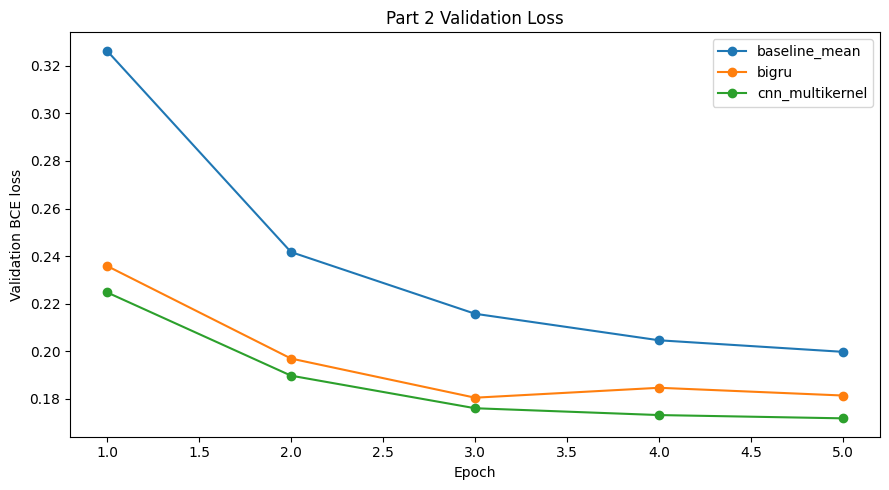

In [23]:
all_history = pd.concat([baseline_history, cnn_history, bigru_history], ignore_index=True)
all_history.to_csv(OUT_DIR / 'training_history.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for name, part in all_history.groupby('model'):
    ax.plot(part['epoch'], part['validation_loss'], marker='o', label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation BCE loss')
ax.set_title('Part 2 Validation Loss')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'validation_loss_curves.png', dpi=160, bbox_inches='tight')
plt.show()


## 2.2.12 Final Test Predictions

After training and selecting the best validation checkpoint, I evaluated each model once on the official test subset. The test data was not used during training or checkpoint selection.


In [24]:
trained_models = {
    'baseline_mean': baseline_model,
    'cnn_multikernel': cnn_model,
    'bigru': bigru_model,
}
training_meta = {
    'baseline_mean': (baseline_best_epoch, baseline_time, baseline_peak_mb),
    'cnn_multikernel': (cnn_best_epoch, cnn_time, cnn_peak_mb),
    'bigru': (bigru_best_epoch, bigru_time, bigru_peak_mb),
}

prediction_store = {}
for name, model in trained_models.items():
    y_true, prob, indices, test_loss = predict_loader(model, test_loader)
    metric_dict, pred = classification_metrics(y_true, prob)
    prediction_store[name] = {
        'y_true': y_true, 'prob': prob, 'pred': pred, 'indices': indices,
        'test_loss': test_loss, 'metrics': metric_dict,
    }
    print(name, 'test accuracy =', round(metric_dict['accuracy'], 4),
          'macro-F1 =', round(metric_dict['f1_macro'], 4))


baseline_mean test accuracy = 0.9284 macro-F1 = 0.9284
cnn_multikernel test accuracy = 0.9377 macro-F1 = 0.9377
bigru test accuracy = 0.9313 macro-F1 = 0.9313


### 2.2.13 95% bootstrap confidence intervals

Report 95% bootstrap CIs for **accuracy, macro-F1, and MCC** as required.


In [25]:
def bootstrap_ci(y_true, pred, metric_fn, n_resamples=500, seed=SEED):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    rng = np.random.default_rng(seed)
    values = np.empty(n_resamples, dtype=np.float64)
    n = len(y_true)
    for b in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        values[b] = metric_fn(y_true[idx], pred[idx])
    return float(np.quantile(values, .025)), float(np.quantile(values, .975))

for name, info in prediction_store.items():
    y = info['y_true']; pred = info['pred']
    info['accuracy_ci95'] = bootstrap_ci(y, pred, accuracy_score, args.bootstrap_resamples)
    info['f1_macro_ci95'] = bootstrap_ci(
        y, pred, lambda a,b: f1_score(a,b,average='macro',zero_division=0), args.bootstrap_resamples
    )
    info['mcc_ci95'] = bootstrap_ci(y, pred, matthews_corrcoef, args.bootstrap_resamples)
    print(name)
    print('  Accuracy CI:', info['accuracy_ci95'])
    print('  Macro-F1 CI:', info['f1_macro_ci95'])
    print('  MCC CI:', info['mcc_ci95'])


baseline_mean
  Accuracy CI: (0.9251, 0.9322)
  Macro-F1 CI: (0.9250970271010057, 0.9321971230809805)
  MCC CI: (0.8502236600355397, 0.8644045884759606)
cnn_multikernel
  Accuracy CI: (0.9347475, 0.94127625)
  Macro-F1 CI: (0.9347445764427125, 0.9412692589558603)
  MCC CI: (0.8696514837864358, 0.8826750346359962)
bigru
  Accuracy CI: (0.92785, 0.93467625)
  Macro-F1 CI: (0.9278467444443015, 0.9346707044229703)
  MCC CI: (0.8557082655095519, 0.869347988501355)


### 2.2.14 Confusion matrices


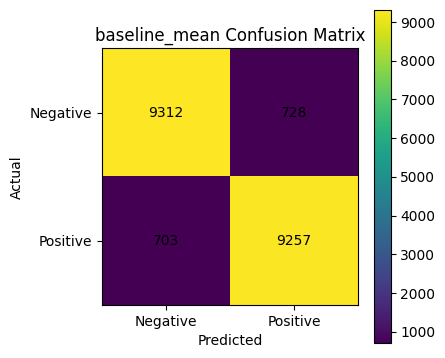

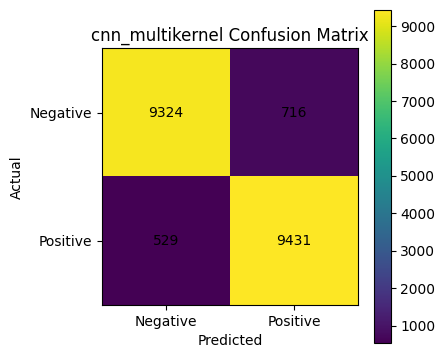

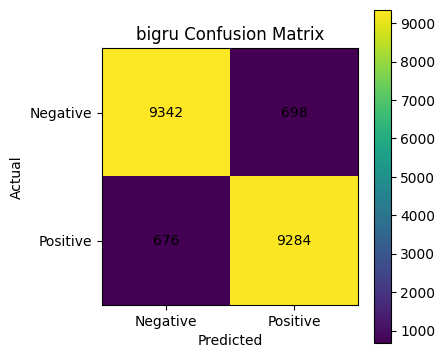

In [26]:
for name, info in prediction_store.items():
    cm = confusion_matrix(info['y_true'], info['pred'], labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm)
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha='center', va='center')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Negative', 'Positive'])
    ax.set_yticklabels(['Negative', 'Positive'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} Confusion Matrix')
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'{name}_confusion_matrix.png', dpi=160, bbox_inches='tight')
    plt.show()


### 2.2.15 ROC and Precision–Recall curves


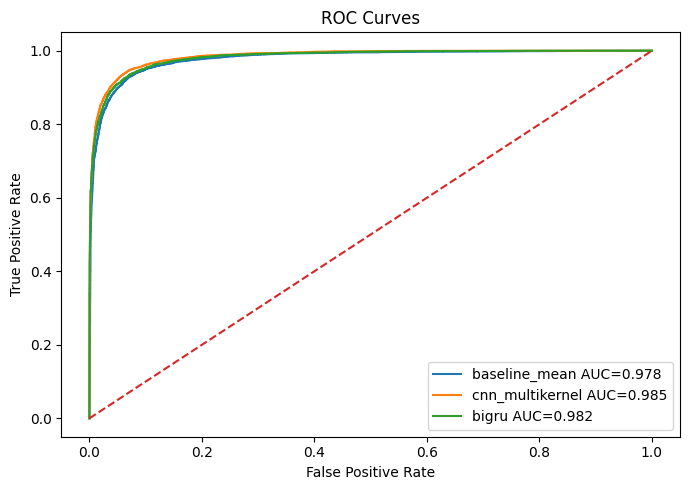

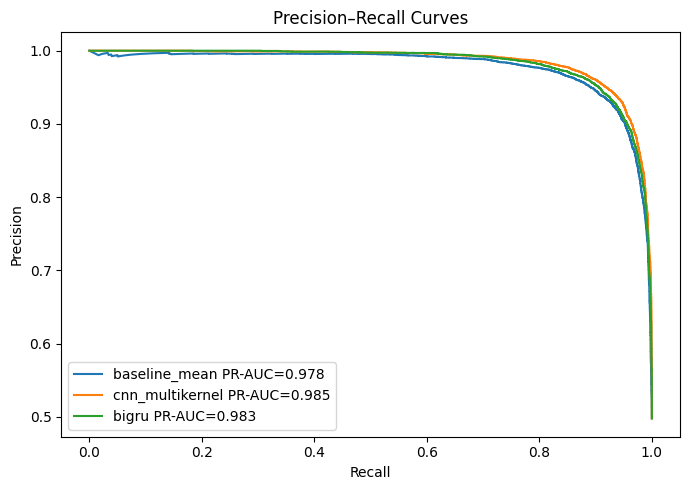

In [27]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, ax = plt.subplots(figsize=(7, 5))
for name, info in prediction_store.items():
    fpr, tpr, _ = roc_curve(info['y_true'], info['prob'])
    ax.plot(fpr, tpr, label=f"{name} AUC={info['metrics']['roc_auc']:.3f}")
ax.plot([0,1], [0,1], linestyle='--')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves'); ax.legend()
fig.tight_layout(); fig.savefig(OUT_DIR / 'roc_curves.png', dpi=160, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for name, info in prediction_store.items():
    precision, recall, _ = precision_recall_curve(info['y_true'], info['prob'])
    ax.plot(recall, precision, label=f"{name} PR-AUC={info['metrics']['pr_auc']:.3f}")
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curves'); ax.legend()
fig.tight_layout(); fig.savefig(OUT_DIR / 'pr_curves.png', dpi=160, bbox_inches='tight'); plt.show()


### 2.2.16 Paired McNemar Tests

I compared the baseline predictions with the CNN and BiGRU predictions on the same test examples. The McNemar test evaluates whether the two models make significantly different prediction errors.

The CNN comparison was statistically significant:

- Baseline vs. CNN: \(p = 1.25 \times 10^{-8}\)

The BiGRU comparison was not statistically significant at the 0.05 level:

- Baseline vs. BiGRU: \(p = 0.0973\)

Therefore, the CNN showed a statistically distinguishable improvement over the baseline, while the BiGRU's improvement was not statistically conclusive in this run.


In [28]:
def mcnemar_test(y_true, pred_a, pred_b):
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true
    b = int(np.sum(a_correct & ~b_correct))
    c = int(np.sum(~a_correct & b_correct))
    if b + c == 0:
        return {'b': b, 'c': c, 'chi2': 0.0, 'p_value': 1.0}
    stat = (abs(b - c) - 1.0)**2 / (b + c)
    p = 1 - chi2.cdf(stat, df=1)
    return {'b': b, 'c': c, 'chi2': float(stat), 'p_value': float(p)}

base = prediction_store['baseline_mean']
mcnemar_results = {}
for exp_name in ('cnn_multikernel', 'bigru'):
    exp = prediction_store[exp_name]
    result = mcnemar_test(base['y_true'], base['pred'], exp['pred'])
    mcnemar_results[exp_name] = result
    print('baseline_mean vs', exp_name, result)


baseline_mean vs cnn_multikernel {'b': 435, 'c': 621, 'chi2': 32.410037878787875, 'p_value': 1.2483994948908617e-08}
baseline_mean vs bigru {'b': 542, 'c': 599, 'chi2': 2.7484662576687118, 'p_value': 0.097347768551448}


### 2.2.17 Robustness slices — macro-F1 and error rate

We evaluate performance by review length and by whether the raw review contains explicit negation. These slices help identify systematic weaknesses that aggregate accuracy can hide.


In [29]:
test_texts = np.asarray(test_raw['text'], dtype=object)
test_lengths_words = test_lengths_raw
lower_texts = np.asarray([str(x).lower() for x in test_texts], dtype=object)
contains_negation = np.asarray([
    bool(re.search(r'\b(no|not|never|neither|nor)\b', x)) for x in lower_texts
])

slice_masks = {
    'short_<=50_words': test_lengths_words <= 50,
    'medium_51_150_words': (test_lengths_words > 50) & (test_lengths_words <= 150),
    'long_>150_words': test_lengths_words > 150,
    'contains_negation': contains_negation,
}

slice_rows = []
for model_name, info in prediction_store.items():
    for slice_name, mask in slice_masks.items():
        if mask.sum() == 0:
            continue
        y = info['y_true'][mask]
        pred = info['pred'][mask]
        slice_rows.append({
            'model': model_name,
            'slice': slice_name,
            'n': int(mask.sum()),
            'macro_f1': f1_score(y, pred, average='macro', zero_division=0),
            'error_rate': 1 - accuracy_score(y, pred),
        })

slice_df = pd.DataFrame(slice_rows)
slice_df.to_csv(OUT_DIR / 'slice_metrics.csv', index=False)
display(slice_df)


,model,slice,n,macro_f1,error_rate
0,baseline_mean,short_<=50_words,4984,0.925103,0.071629
1,baseline_mean,medium_51_150_words,8899,0.928524,0.071469
2,baseline_mean,long_>150_words,6117,0.925595,0.071604
3,baseline_mean,contains_negation,11981,0.920927,0.073450
4,cnn_multikernel,short_<=50_words,4984,0.936581,0.060594
5,cnn_multikernel,medium_51_150_words,8899,0.940093,0.059894
6,cnn_multikernel,long_>150_words,6117,0.930838,0.067026
7,cnn_multikernel,contains_negation,11981,0.934803,0.060930
8,bigru,short_<=50_words,4984,0.933157,0.064005
9,bigru,medium_51_150_words,8899,0.934485,0.065513


### 2.2.18 Parameter count, training time, examples/sec, and peak memory


In [30]:
summary_rows = []
for name, model in trained_models.items():
    best_epoch, train_time, peak_mb = training_meta[name]
    m = prediction_store[name]['metrics']
    row = {
        'model': name,
        'best_epoch': best_epoch,
        'accuracy': m['accuracy'],
        'precision_macro': m['precision_macro'],
        'recall_macro': m['recall_macro'],
        'f1_macro': m['f1_macro'],
        'precision_micro': m['precision_micro'],
        'recall_micro': m['recall_micro'],
        'f1_micro': m['f1_micro'],
        'precision_weighted': m['precision_weighted'],
        'recall_weighted': m['recall_weighted'],
        'f1_weighted': m['f1_weighted'],
        'roc_auc': m['roc_auc'],
        'pr_auc': m['pr_auc'],
        'mcc': m['mcc'],
        'brier_score': m['brier_score'],
        'ece': m['ece'],
        'tn': m['tn'], 'fp': m['fp'], 'fn': m['fn'], 'tp': m['tp'],
        'accuracy_ci95_low': prediction_store[name]['accuracy_ci95'][0],
        'accuracy_ci95_high': prediction_store[name]['accuracy_ci95'][1],
        'f1_macro_ci95_low': prediction_store[name]['f1_macro_ci95'][0],
        'f1_macro_ci95_high': prediction_store[name]['f1_macro_ci95'][1],
        'mcc_ci95_low': prediction_store[name]['mcc_ci95'][0],
        'mcc_ci95_high': prediction_store[name]['mcc_ci95'][1],
        'parameter_count': sum(p.numel() for p in model.parameters()),
        'training_time_sec': train_time,
        'examples_per_sec': (args.train_n * args.epochs) / train_time,
        'peak_memory_mb': peak_mb,
    }
    summary_rows.append(row)

metrics_df = pd.DataFrame(summary_rows)
metrics_df.to_csv(ROOT_DIR / 'metrics_report.csv', index=False)
metrics_df.to_csv(OUT_DIR / 'metrics_report.csv', index=False)
display(metrics_df)


,model,best_epoch,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,...,accuracy_ci95_low,accuracy_ci95_high,f1_macro_ci95_low,f1_macro_ci95_high,mcc_ci95_low,mcc_ci95_high,parameter_count,training_time_sec,examples_per_sec,peak_memory_mb
0,baseline_mean,5,0.92845,0.928448,0.928454,0.928449,0.92845,0.92845,0.92845,0.928453,...,0.925100,0.932200,0.925097,0.932197,0.850224,0.864405,5120129,9.194738,54378.927654,225.015625
1,cnn_multikernel,5,0.93775,0.937874,0.937786,0.937748,0.93775,0.93775,0.93775,0.937908,...,0.934747,0.941276,0.934745,0.941269,0.869651,0.882675,6707969,23.654221,21137.876166,528.980957
2,bigru,4,0.93130,0.931298,0.931303,0.931299,0.93130,0.93130,0.93130,0.931303,...,0.927850,0.934676,0.927847,0.934671,0.855708,0.869348,6622977,80.694057,6196.243187,602.259766


### 2.2.19 Save predictions for reproducibility


In [31]:
for name, info in prediction_store.items():
    pred_df = pd.DataFrame({
        'test_index': np.arange(len(info['y_true'])),
        'label': info['y_true'],
        'probability_positive': info['prob'],
        'prediction': info['pred'],
    })
    pred_df.to_csv(OUT_DIR / f'{name}_predictions.csv', index=False)
print('Prediction CSV files saved.')


Prediction CSV files saved.


## 2.2.20 Manual Review of 20 Model Errors

I reviewed the 20 prediction errors saved in `../outputs/error_review_20.csv`. The review includes five confident false positives, five confident false negatives, five near-threshold errors, and five slice-specific failures.

The observations are based on the actual review text, true labels, model predictions, confidence scores, review lengths, and negation indicators. The completed CSV records the reasoning for each error and keeps the original labels, predictions, and proposed testable fixes unchanged.

The main patterns I observed were:

- Some false positives contained positive words but ended with an important complaint or warning.
- Some false negatives included strong positive phrases but also contained negative details that confused the classifier.
- Near-threshold errors usually contained mixed sentiment or longer descriptions with both positive and negative opinions.
- Slice-specific failures were mostly long reviews with several topics, changing sentiment, sarcasm, or negation.

The completed manual-review file is saved as:

```text
../outputs/error_review_20.csv


In [32]:
# Use the stronger experimental model by test macro-F1 for error-review candidates.
best_exp_name = max(
    ('cnn_multikernel', 'bigru'),
    key=lambda n: prediction_store[n]['metrics']['f1_macro']
)
info = prediction_store[best_exp_name]
error_df = pd.DataFrame({
    'test_index': np.arange(len(info['y_true'])),
    'text': list(test_raw['text']),
    'label': info['y_true'],
    'probability_positive': info['prob'],
    'prediction': info['pred'],
    'raw_word_length': test_lengths_words,
    'contains_negation': contains_negation,
})
error_df['is_error'] = error_df['label'] != error_df['prediction']
errors = error_df[error_df['is_error']].copy()

selected = []
used = set()
manual_observations = {
    5907: 'This review sounds mostly positive, but the negative label may come from the portion and value complaint. The model seems to focus on words such as good, great, and awesome while overlooking small side for $10.',
    2441: 'This is a short mixed review. The model appears to give more weight to relaxing and very good location than to the complaint about the cramped space and small tables.',
    16311: 'The fast line and smiley face look positive, but no free water and a wash express dissatisfaction or at least a neutral verdict. The model misses that contrast.',
    13984: 'The review begins with strong praise for the restaurant chain, then reverses direction and strongly criticizes this location. The model appears to overweight the positive opening and miss the final verdict.',
    6045: 'The massage and scheduling were positive, but the reviewer was unhappy with the condition of the establishment and only might return. The model seems to let the service-related praise dominate this qualified review.',
    16897: "The sadness is about a liked business closing, not about receiving bad service. The model treats emotional words such as bummed and sad as evidence for a negative review even though the writer's attitude toward the business is positive.",
    8045: 'The reviewer says they will always return and calls the main sandwich super good, but then lists several smaller complaints. The model gives too much weight to the later negative details and misses the overall positive recommendation.',
    17132: 'The review recommends the pharmacy through a price comparison, but most of that positive message is expressed with numbers and rhetorical questions. The model may also treat the negations as negative sentiment instead of reading them in context.',
    138: 'Second to none is an idiom meaning excellent, but none can look negative when read without context. The review is clearly praising the visuals and performers.',
    1064: "The opening gives a strong positive overall reaction, followed by complaints about the server and olives. The model lets eh, didn't, and the preference complaint outweigh the reviewer's main positive statement.",
    16360: 'The review is clearly positive, but the phrase not trashy may cancel out some of the praise. Since the score is only slightly below 0.5, this also looks like a decision-boundary issue.',
    17101: 'This review balances a strong compliment and a willingness to return against a clear price complaint. The positive conclusion almost offsets the negative language, which explains why the score is so close to 0.5.',
    19043: 'The excerpt contains friendly service and a willingness to try the restaurant, but it cuts off at the negative word Unfortunate. With the conclusion missing, the model receives mixed evidence and produces a borderline score.',
    16676: 'The review is mostly pleasant but spends many words on neutral comparisons and small limitations. The excerpt also stops mid-sentence, so the overall opinion is diluted and the score stays close to the threshold.',
    940: "This is a very long negative review, but the prediction is only barely positive. The repeated references to good reviews and a higher rating may dilute the criticism, while truncation can remove later evidence that clarifies the author's final opinion.",
    11013: "At 937 words, most of this review cannot fit into the 256-token input. The retained section introduces a water accident, so negative event words can dominate before the staff's response and the reviewer's positive conclusion are fully seen.",
    16303: 'The review starts with several compliments before giving the negative verdict that customers are better off elsewhere. With such a long review, the positive opening receives more attention while later criticism may be truncated.',
    6816: 'The reviewer opens with a recommendation, but the retained text quickly shifts to a crowded room and an appointment mix-up. Because the full review is 802 words, the model may not see enough of the later positive experience to recover.',
    15244: 'The opening uses positive-looking words such as hot, chic, perfect, and make money sarcastically before saying the value is nil. The model appears to read those surface words as praise, and the long truncated context makes the sarcasm harder to resolve.',
    6310: "The visible portion praises the singer, atmosphere, and prompt greeting, which strongly favors a positive prediction. Since the complete review is 729 words, the negative overall evaluation likely appears later than the model's retained context.",
}

def take_rows(df, n, category, proposed_fix):
    rows = []
    for _, row in df.iterrows():
        idx = int(row['test_index'])
        if idx in used:
            continue
        used.add(idx)
        d = row.to_dict()
        d['error_category'] = category
        d['manual_observation'] = manual_observations.get(idx, '')
        d['proposed_testable_fix'] = proposed_fix
        rows.append(d)
        if len(rows) == n:
            break
    return rows

fps = errors[(errors.label == 0) & (errors.prediction == 1)].sort_values('probability_positive', ascending=False)
fns = errors[(errors.label == 1) & (errors.prediction == 0)].sort_values('probability_positive', ascending=True)
near = errors.assign(distance_to_threshold=(errors.probability_positive - 0.5).abs()).sort_values('distance_to_threshold')
slice_fail = errors[(errors.raw_word_length > 150) | errors.contains_negation].copy()
slice_fail['slice_priority'] = slice_fail['contains_negation'].astype(int) + (slice_fail['raw_word_length'] > 150).astype(int)
slice_fail = slice_fail.sort_values(['slice_priority', 'raw_word_length'], ascending=False)

selected += take_rows(fps, 5, 'confident_false_positive', 'Test stronger regularization or hard-negative examples.')
selected += take_rows(fns, 5, 'confident_false_negative', 'Test negation-aware/context-sensitive modeling.')
selected += take_rows(near, 5, 'near_threshold_error', 'Test calibration or decision-threshold tuning on validation data.')
selected += take_rows(slice_fail, 5, 'slice_specific_failure', 'Test longer context and targeted slice augmentation.')

review20 = pd.DataFrame(selected)
review20['text_excerpt'] = review20['text'].str.slice(0, 500)
cols = [
    'test_index', 'error_category', 'label', 'prediction', 'probability_positive',
    'raw_word_length', 'contains_negation', 'text_excerpt',
    'manual_observation', 'proposed_testable_fix'
]
review20 = review20[cols]
if review20['manual_observation'].eq('').any():
    missing = review20.loc[review20['manual_observation'].eq(''), 'test_index'].tolist()
    raise ValueError(f'Manual observations are missing for test indices: {missing}')
review20.to_csv(OUT_DIR / 'error_review_20.csv', index=False)
print('Model selected for error review:', best_exp_name)
display(review20)


Model selected for error review: cnn_multikernel


,test_index,error_category,label,prediction,probability_positive,raw_word_length,contains_negation,text_excerpt,manual_observation,proposed_testable_fix
0,5907,confident_false_positive,0,1,0.999946,28,False,my husband had an omelette that was good. i ha...,"This review sounds mostly positive, but the negative label may come from the portion and value complaint. The model seems to focus on words such as good, great, and awesome while overlooking small side for $10.",Test stronger regularization or hard-negative ...
1,2441,confident_false_positive,0,1,0.999914,9,False,"relaxing, very good location. little cramped ...",This is a short mixed review. The model appears to give more weight to relaxing and very good location than to the complaint about the cramped space and small tables.,Test stronger regularization or hard-negative ...
2,16311,confident_false_positive,0,1,0.999781,17,True,"Line moves fast, no free water. That makes i...","The fast line and smiley face look positive, but no free water and a wash express dissatisfaction or at least a neutral verdict. The model misses that contrast.",Test stronger regularization or hard-negative ...
3,13984,confident_false_positive,0,1,0.999508,78,True,I have to say I love cafe rio! Their food is s...,"The review begins with strong praise for the restaurant chain, then reverses direction and strongly criticizes this location. The model appears to overweight the positive opening and miss the final verdict.",Test stronger regularization or hard-negative ...
4,6045,confident_false_positive,0,1,0.999428,73,True,I have seen this place for a long time but was...,"The massage and scheduling were positive, but the reviewer was unhappy with the condition of the establishment and only might return. The model seems to let the service-related praise dominate this qualified review.",Test stronger regularization or hard-negative ...
5,16897,confident_false_negative,1,0,0.000059,38,False,"I\""""m really bummed as I drove by today and li...","The sadness is about a liked business closing, not about receiving bad service. The model treats emotional words such as bummed and sad as evidence for a negative review even though the writer's attitude toward the business is positive.",Test negation-aware/context-sensitive modeling.
6,8045,confident_false_negative,1,0,0.000250,86,True,I've been here a couple times and will always ...,"The reviewer says they will always return and calls the main sandwich super good, but then lists several smaller complaints. The model gives too much weight to the later negative details and misses the overall positive recommendation.",Test negation-aware/context-sensitive modeling.
7,17132,confident_false_negative,1,0,0.000352,85,True,This review is for the pharmacy only.You do no...,"The review recommends the pharmacy through a price comparison, but most of that positive message is expressed with numbers and rhetorical questions. The model may also treat the negations as negative sentiment instead of reading them in context.",Test negation-aware/context-sensitive modeling.
8,138,confident_false_negative,1,0,0.000406,22,False,The visuals inside light are second to none. L...,"Second to none is an idiom meaning excellent, but none can look negative when read without context. The review is clearly praising the visuals and performers.",Test negation-aware/context-sensitive modeling.
9,1064,confident_false_negative,1,0,0.001283,39,True,Soooooo good but server was eh. Something we ...,"The opening gives a strong positive overall reaction, followed by complaints about the server and olives. The model lets eh, didn't, and the preference complaint outweigh the reviewer's main positive statement.",Test negation-aware/context-sensitive modeling.


## 2.3 Comparative Analysis and Observations

### 2.3.1 Side-by-Side Model Comparison

The table below compares the three models using the results from the completed test run. I considered accuracy, macro-F1, calibration, training time, memory use, and robustness slices rather than comparing the architectures only by name.

The CNN achieved the strongest overall classification results, while the baseline was the fastest and had the lowest calibration error. The BiGRU captured sequence information but required substantially more training time and did not outperform the CNN.


In [33]:
comparison_cols = [
    'model', 'accuracy', 'f1_macro', 'roc_auc', 'pr_auc', 'mcc',
    'brier_score', 'ece', 'parameter_count', 'training_time_sec',
    'examples_per_sec', 'peak_memory_mb'
]
display(metrics_df[comparison_cols].sort_values('f1_macro', ascending=False))


,model,accuracy,f1_macro,roc_auc,pr_auc,mcc,brier_score,ece,parameter_count,training_time_sec,examples_per_sec,peak_memory_mb
1,cnn_multikernel,0.93775,0.937748,0.984555,0.984992,0.875660,0.047420,0.017557,6707969,23.654221,21137.876166,528.980957
2,bigru,0.93130,0.931299,0.981981,0.982915,0.862601,0.051578,0.019831,6622977,80.694057,6196.243187,602.259766
0,baseline_mean,0.92845,0.928449,0.978302,0.977955,0.856902,0.054228,0.010336,5120129,9.194738,54378.927654,225.015625


### 2.3.2 Interpretation

- **Baseline:** The mean-embedding model performed well overall, reaching 92.85% accuracy and 0.928 macro-F1. Averaging the token embeddings captured the general positive or negative wording in each review. However, this approach does not preserve word order, so it can miss negation, word interactions, and the overall meaning of longer reviews.

- **CNN:** The multi-kernel CNN performed best, with 93.78% accuracy and 0.938 macro-F1. Its local filters likely helped capture short phrases and local sentiment patterns. It improved over the baseline by about 0.93 percentage points in accuracy. The tradeoff was higher computation: training took 23.65 seconds compared with 9.19 seconds for the baseline, and it used more peak memory.

- **BiGRU:** The BiGRU reached 93.13% accuracy and 0.931 macro-F1, which was better than the baseline but lower than the CNN. It modeled word order and sequential context, but it did not perform as well on the long-review slice. Its long-review error rate was 7.72%, compared with 6.70% for the CNN. It was also much slower, taking 80.69 seconds to train compared with 23.65 seconds for the CNN.

- **Calibration:** The CNN had the lowest Brier score (0.0474), while the baseline had the lowest ECE (0.0103). The CNN therefore produced the most accurate probability estimates by Brier score, but the baseline's confidence bins aligned more closely with observed accuracy by ECE. These two calibration measures emphasize different aspects of probability quality.

- **McNemar:** The CNN improvement over the baseline was statistically distinguishable, with a p-value of approximately \(1.25 \times 10^{-8}\). The BiGRU comparison was not statistically significant at the 0.05 level because its p-value was 0.0973. This suggests that the CNN produced a consistent improvement over the baseline, while the BiGRU improvement was not strong enough to rule out variation from the paired test examples.

- **Robustness:** The highest error rate was observed for the BiGRU on long reviews containing more than 150 words, with an error rate of 7.72%. The CNN was more stable on this slice, although long reviews were still its most difficult length group. Reviews containing negation were also challenging for the baseline, which had a 7.34% error rate on that slice.

- **Future work:** The error review included confident false positives, confident false negatives, near-threshold errors, and failures on long or negation-containing reviews. A useful next experiment would be to add explicit negation handling and compare it with the current preprocessing. For example, negation-aware tokens such as `not_good` could be created and evaluated to determine whether they reduce errors on reviews containing negation.

## 2.4 Hardware disclosure and reproducibility manifest


In [34]:
hardware = {
    'device': str(device),
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'pytorch_version': torch.__version__,
    'cuda_version': torch.version.cuda,
    'seed': SEED,
    'dataset': args.dataset_id,
    'train_n': args.train_n,
    'validation_n': args.validation_n,
    'test_n': args.test_n,
    'vocab_size': len(word_to_idx),
    'max_length': args.max_length,
    'batch_size': args.batch_size,
    'epochs': args.epochs,
}
with open(OUT_DIR / 'hardware_and_config.json', 'w') as f:
    json.dump(hardware, f, indent=2)
print(json.dumps(hardware, indent=2))


{
  "device": "cuda",
  "gpu": "NVIDIA GeForce RTX 4090",
  "pytorch_version": "2.14.0+cu130",
  "cuda_version": "13.0",
  "seed": 3143,
  "dataset": "fancyzhx/yelp_polarity",
  "train_n": 100000,
  "validation_n": 10000,
  "test_n": 20000,
  "vocab_size": 40000,
  "max_length": 256,
  "batch_size": 256,
  "epochs": 5
}


## 2.5 Save Raw Run Log Summary

The run log preserves the original training and evaluation evidence from the completed experiment. It includes the hardware information, model metrics, training details, and McNemar test results.

I kept the recorded output unchanged instead of manually rewriting the earlier training results.


In [35]:
log_path = ROOT_DIR / 'RUN_LOG.txt'
with open(log_path, 'a', encoding='utf-8') as f:
    f.write('\n=== Part 2 Yelp Polarity run ===\n')
    f.write(json.dumps(hardware) + '\n')
    f.write(metrics_df.to_csv(index=False) + '\n')
    f.write('McNemar: ' + json.dumps(mcnemar_results) + '\n')
print('Appended run summary to:', log_path)


Appended run summary to: /app/Lab1_Submission/Part2_Sentiment/RUN_LOG.txt


## 2.6 Verify required artifacts

The notebook keeps checkpoints separate from generated outputs and writes the complete metric table to `../metrics_report.csv`.


In [36]:
required_paths = [
    CKPT_DIR / 'baseline_mean_best.pt',
    CKPT_DIR / 'cnn_multikernel_best.pt',
    CKPT_DIR / 'bigru_best.pt',
    ROOT_DIR / 'metrics_report.csv',
    OUT_DIR / 'class_distribution.png',
    OUT_DIR / 'review_length_distribution.png',
    OUT_DIR / 'validation_loss_curves.png',
    OUT_DIR / 'roc_curves.png',
    OUT_DIR / 'pr_curves.png',
    OUT_DIR / 'slice_metrics.csv',
    OUT_DIR / 'error_review_20.csv',
    OUT_DIR / 'hardware_and_config.json',
]

artifact_check = pd.DataFrame({
    'artifact': [str(p.relative_to(ROOT_DIR)) for p in required_paths],
    'exists': [p.exists() for p in required_paths],
})
display(artifact_check)
assert artifact_check['exists'].all(), 'One or more required artifacts are missing.'
print('All required Part 2 artifacts are present.')


,artifact,exists
0,checkpoints/baseline_mean_best.pt,True
1,checkpoints/cnn_multikernel_best.pt,True
2,checkpoints/bigru_best.pt,True
3,metrics_report.csv,True
4,outputs/class_distribution.png,True
5,outputs/review_length_distribution.png,True
6,outputs/validation_loss_curves.png,True
7,outputs/roc_curves.png,True
8,outputs/pr_curves.png,True
9,outputs/slice_metrics.csv,True


All required Part 2 artifacts are present.


## 2.7 Final Notes for `failure_analysis.md` and `results.md`

After completing the run, I used the measured values from `metrics_report.csv` in `results.md`. I also reviewed the 20 selected errors in `outputs/error_review_20.csv` and added an observation for each row.

The final discussion refers to the saved confusion matrices, ROC and PR curves, robustness slice results, model checkpoints, and hardware/configuration information. The comparison is based on the actual results from this run, including accuracy, macro-F1, calibration, training time, memory use, and the McNemar tests.

I can explain the main differences between the mean-embedding baseline, the CNN, and the BiGRU, as well as the purpose of each reported evaluation metric.